In [ ]:
!pip uninstall -y numpy pandas scikit-learn pmdarima Cython packaging setuptools statsmodels scipy mapie
!pip install pmdarima==2.0.4
!pip install pandas==2.2.2 scikit-learn==1.6.1 statsmodels==0.14.4 setuptools==69.5.1 packaging==23.2 Cython==3.1.2 scipy==1.11.4 mapie==0.6.0
!pip install arch

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: Cython 3.0.12
Uninstalling Cython-3.0.12:
  Successfully uninstalled Cython-3.0.12
Found existing installation: packaging 25.0
Uninstalling packaging-25.0:
  Successfully uninstalled packaging-25.0
Found existing installation: setuptools 75.2.0
Uninstalling setuptools-75.2.0:
  Successfully uninstalled setuptools-75.2.0
Found existing installation: statsmodels 0.14.5
Uninstalling statsmodels-0.14.5:
  Successfully uninstalled statsmodels-0.14.5
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.9.0
    Uninstalling setuptools-80.9.0:
      Suc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import plotly.graph_objects as go
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_percentage_error as mape
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HW
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_percentage_error as mape
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
from scipy.stats import shapiro
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima import auto_arima
from arch import arch_model

In [ ]:
df = pd.read_excel('Taxa Desemprego Brasil.xlsx')
df.head()

,Data,Desemprego
0,2012-01-01,0.080
1,2012-02-01,0.078
2,2012-03-01,0.077
3,2012-04-01,0.076
4,2012-05-01,0.075


In [ ]:
valor=pd.Series(df.iloc[:,1].values,
                  index=pd.date_range(start='2012-01-01', periods=len(df),
                                      freq='ME'))
# Separar treino e teste por janela de dados
bdf = valor[:-12]
reaisdf = valor[-12:]

Melhor configuração: {'trend': 'add', 'seasonal': 'add'} com AIC = -1798.3404315896298
                       ExponentialSmoothing Model Results                       
Dep. Variable:                     None   No. Observations:                  139
Model:             ExponentialSmoothing   SSE                              0.000
Optimized:                         True   AIC                          -1798.340
Trend:                         Additive   BIC                          -1751.389
Seasonal:                      Additive   AICC                         -1792.640
Seasonal Periods:                    12   Date:                 Wed, 05 Nov 2025
Box-Cox:                          False   Time:                         18:31:51
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level     

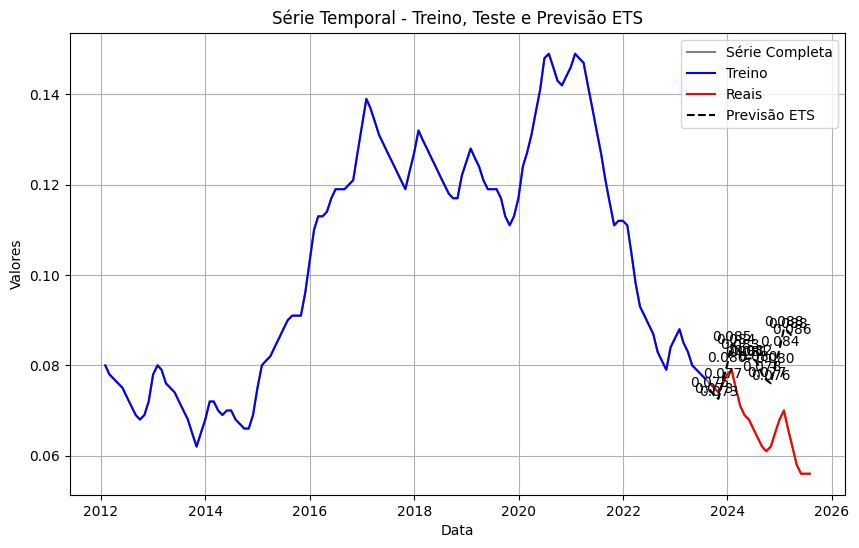

In [ ]:
# MODELO ETS
modelos_df = []
mapes_df = []
previsoes_df = {}
# Definir todas as combinações possíveis de modelos para ETS
configs = [
 {'trend': None, 'seasonal': None},
 {'trend': 'add', 'seasonal': None},
 {'trend': None, 'seasonal': 'add'},
 {'trend': 'add', 'seasonal': 'add'},
 {'trend': 'mul', 'seasonal': None},
 {'trend': None, 'seasonal': 'mul'},
 {'trend': 'mul', 'seasonal': 'mul'},
 {'trend': 'add', 'seasonal': 'mul'},
 {'trend': 'mul', 'seasonal': 'add'}
]
best_aic = float('inf')
best_config = None
best_model = None
# Ajustar os modelos com diferentes configurações e comparar AIC
for config in configs:
  try:
      model = ExponentialSmoothing(bdf, seasonal_periods=12, trend=config['trend'], seasonal=config['seasonal']).fit()
      aic = model.aic
      if aic < best_aic:
          best_aic = aic
          best_config = config
          best_model = model
  except Exception as e:
      pass  # Ignorar configurações que não funcionam
     # In[111]: Exibir o melhor modelo com base no AIC
print(f"Melhor configuração: {best_config} com AIC = {best_aic}")
print(best_model.summary())

# In[112]: Previsão de 20 passos à frente com o melhor modelo
best_forecasts = best_model.forecast(steps=20)
print("Previsão para os próximos 20 períodos:")
print(best_forecasts)
plt.figure(figsize=(10, 6))
plt.plot(valor.index, valor, label="Série Completa", color='gray')
plt.plot(bdf.index, bdf, label="Treino", color='blue')
plt.plot(reaisdf.index, reaisdf, label="Reais", color='red')
plt.plot(best_forecasts.index, best_forecasts, label="Previsão ETS", color='black', linestyle='--')
# Add data labels for "Previsão ETS"
for date, value in zip(best_forecasts.index, best_forecasts):
    plt.text(date, value, f'{value:.3f}', ha='center', va='bottom')
plt.title("Série Temporal - Treino, Teste e Previsão ETS")
plt.xlabel("Data")
plt.ylabel("Valores")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Modelo ARIMA/SARIMA com treino e teste #
try:
    arima_model = auto_arima(bdf, seasonal=True, m=12, stepwise=True, trace=True)
    # Exibir o melhor modelo ARIMA/SARIMA encontrado
    print(f"Melhor modelo ARIMA/SARIMA identificado: {arima_model}")
    # Exibir o resumo estatístico do modelo ARIMA/SARIMA
    print(arima_model.summary())
    # Cálculo do número de períodos do forecast
    last_train_date = bdf.index[-1]
    forecast_end_date = pd.to_datetime('2026-12-31')
    n_periods_forecast = (forecast_end_date.to_period('M') - last_train_date.to_period('M')).n + 1
    arima_forecast = pd.Series(arima_model.predict(n_periods=n_periods_forecast),
    index=pd.date_range(start=bdf.index[-1] + pd.offsets.MonthBegin(1), periods=n_periods_forecast, freq='ME'))
    mape_arima = mape(reaisdf, arima_forecast[:len(reaisdf)]) * 100
    modelos_df.append("ARIMA/SARIMA")
    mapes_df.append(mape_arima)
    previsoes_df["ARIMA/SARIMA"] = arima_forecast
except Exception as e:
    print(f"Erro no modelo ARIMA/SARIMA: {e}")
    modelos_df.append("ARIMA/SARIMA")
    mapes_df.append(np.nan)

In [ ]:
# Modelo ARIMA/SARIMA sem treino e teste #
try:
    # Train the model on the entire dataset
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        arima_model = auto_arima(valor, seasonal=True, m=12, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True, maxiter=100)

    # Exibir o melhor modelo ARIMA/SARIMA encontrado
    print(f"Melhor modelo ARIMA/SARIMA identificado: {arima_model}")
    # Exibir o resumo estatístico do modelo ARIMA/SARIMA
    print(arima_model.summary())
    # Cálculo do número de períodos do forecast
    last_train_date = valor.index[-1] # Use the last date of the entire dataset
    forecast_end_date = pd.to_datetime('2026-12-31')
    n_periods_forecast = (forecast_end_date.to_period('M') - last_train_date.to_period('M')).n + 1
    arima_forecast = pd.Series(arima_model.predict(n_periods=n_periods_forecast),
    index=pd.date_range(start=valor.index[-1] + pd.offsets.MonthBegin(1), periods=n_periods_forecast, freq='ME'))
    # Note: MAPE calculation with reaisdf is no longer relevant as we are not using train/test split
    # mape_arima = mape(reaisdf, arima_forecast[:len(reaisdf)]) * 100
    # modelos_df.append("ARIMA/SARIMA")
    # mapes_df.append(mape_arima)
    previsoes_df["ARIMA/SARIMA"] = arima_forecast
except Exception as e:
    print(f"Erro no modelo ARIMA/SARIMA: {e}")
    # modelos_df.append("ARIMA/SARIMA")
    # mapes_df.append(np.nan)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-1606.109, Time=7.97 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-1415.951, Time=0.36 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,1,2)(2,0,0)[12] intercept   : AIC=-1603.439, Time=3.90 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,1)(2,0,0)[12]             : AIC=-1610.387, Time=1.45 sec

Best model:  ARIMA(3,1,1)(2,0,0)[12] intercept
Total fit time: 78.335 seconds
Melhor modelo ARIMA/SARIMA identificado:  ARIMA(3,1,1)(2,0,0)[12] intercept
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  163
Model:             SARIMAX(3, 1, 1)x(2, 0, [], 12)   Log Likelihood                 820.703
Date:                             Wed, 05 Nov 2025   AIC                          -1625.407
Time:                                     19:01:50   BIC                          -1600.706
Sample:                                 01-31-2012   HQIC                         -1615.378
                                      - 07-31-2025                                         
Covariance Type:                               opg                                         
                 coef    std err         

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


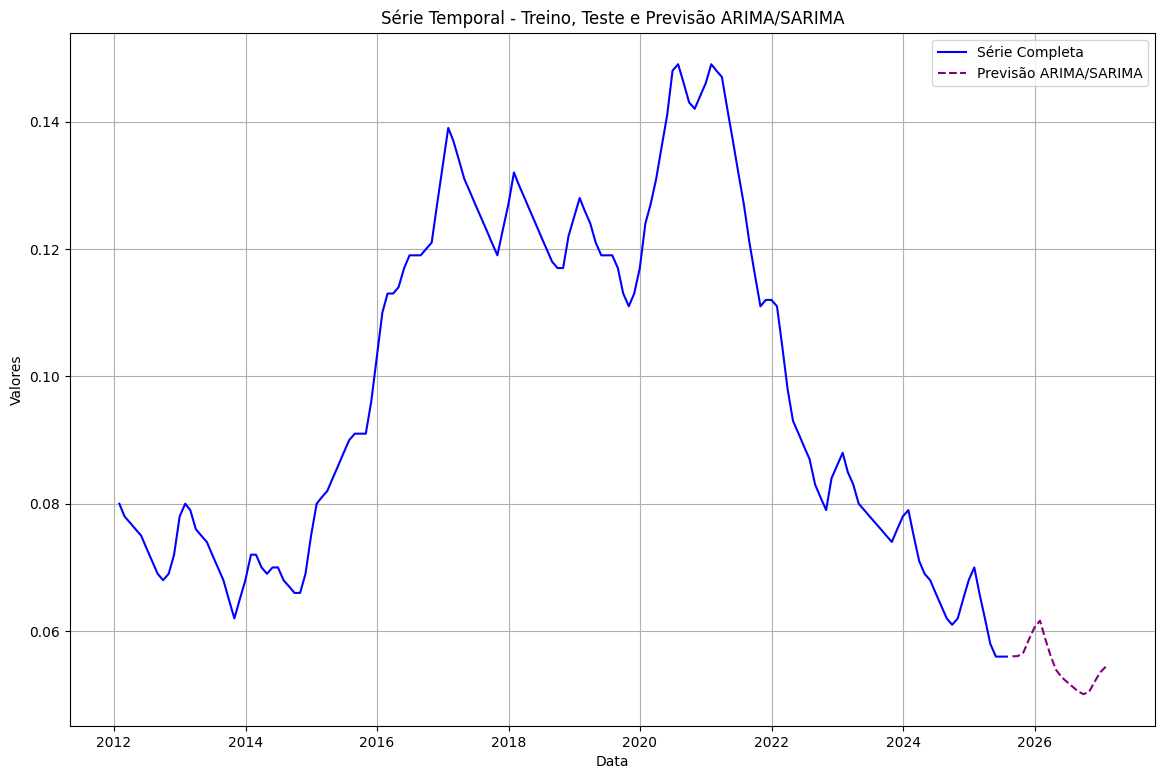

In [ ]:
    plt.figure(figsize=(14, 9))
    plt.plot(valor.index, valor, label="Série Completa", color='blue')
    plt.plot(arima_forecast.index, arima_forecast, label="Previsão ARIMA/SARIMA", color='purple', linestyle='--')
    # Add data labels for "Previsão ARIMA/SARIMA"
    #for date, value in zip(arima_forecast.index, arima_forecast):
    #    plt.text(date, value, f'{value:.3f}', ha='center', va='bottom')
    plt.title("Série Temporal - Treino, Teste e Previsão ARIMA/SARIMA")
    plt.xlabel("Data")
    plt.ylabel("Valores")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
print(arima_forecast)

2025-08-31    0.056046
2025-09-30    0.056077
2025-10-31    0.056661
2025-11-30    0.058669
2025-12-31    0.060556
2026-01-31    0.061643
2026-02-28    0.058906
2026-03-31    0.056118
2026-04-30    0.053931
2026-05-31    0.052771
2026-06-30    0.052025
2026-07-31    0.051271
2026-08-31    0.050531
2026-09-30    0.050095
2026-10-31    0.050486
2026-11-30    0.052025
2026-12-31    0.053518
2027-01-31    0.054405
Freq: ME, dtype: float64


In [ ]:
    # COMPARAÇÃO ENTRE MAPES
    # MAPE ETS
    mape_ets = mape(reaisdf, best_forecasts[:len(reaisdf)]) * 100
    modelos_df.append("ETS")
    mapes_df.append(mape_ets)
    previsoes_df["ETS"] = best_forecasts
    # MAPE ARIMA/SARIMA
    mape_comparison = pd.DataFrame({'Modelo': modelos_df, 'MAPE': mapes_df})
    mape_comparison = mape_comparison.sort_values(by='MAPE', ascending=True).reset_index(drop=True)
    print(mape_comparison)
    # In[236]: Gráfico dos MAPE dos modelos
    plt.figure(figsize=(10, 6))
    plt.barh(mape_comparison['Modelo'], mape_comparison['MAPE'], color='skyblue')
    plt.xlabel("MAPE")
    plt.title("MAPE Comparação de Modelos")
    plt.grid(True)
    plt.show()

In [ ]:
# In[237]: Selecionar o modelo com o menor MAPE
melhor_modelo = mape_comparison.loc[0, 'Modelo']
melhores_previsoes = previsoes_df[melhor_modelo]
# In[238]: Criar gráfico comparando os valores reais e previstos do melhor modelo
plt.figure(figsize=(10, 6))
plt.plot(reaisdf.index, reaisdf, label='Valores Reais', color='blue')
plt.plot(reaisdf.index, melhores_previsoes[:len(reaisdf)], label=f'Previsão - {melhor_modelo}', color='red')
plt.title(f'Valores Reais vs Previsão ({melhor_modelo})')
plt.xlabel('Data')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.show()